# Exploration PCA SQR pour le niveau silver

Objectifs :
- charger les datasets bronze RTE et SQR ;
- extraire la couverture temporelle commune pilotée par RTE ;
- analyser les valeurs manquantes des séries SQR ;
- tester plusieurs PCA sur les températures quotidiennes ;
- choisir un nombre de composantes à partir de la variance expliquée.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import FunctionTransformer

import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
from src.scripts.utils.preprocessing import _forward_fill_impute
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.options.display.max_columns = 0
sns.set_theme(style="whitegrid")

base_data_dir = (Path.cwd().parent / "data").resolve()
bronze_dir = base_data_dir / "bronze"
rte_path = bronze_dir / "rte_annuel_definitif.parquet"
sqr_path = bronze_dir / "sqr_daily_by_station.parquet"

for path in [rte_path, sqr_path]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {path}")

print(f"RTE bronze: {rte_path}")
print(f"SQR bronze: {sqr_path}")

RTE bronze: /home/camille/code/Camille9999/EPSI/M2/EPSI-M2_MSPR/src/data/bronze/rte_annuel_definitif.parquet
SQR bronze: /home/camille/code/Camille9999/EPSI/M2/EPSI-M2_MSPR/src/data/bronze/sqr_daily_by_station.parquet


In [8]:
def build_rte_daily_coverage(rte_df: pd.DataFrame) -> pd.DataFrame:
    coverage_df = rte_df.copy()

    coverage_df["Nature"] = pd.to_datetime(coverage_df["Nature"], errors="coerce")
    coverage_df = coverage_df.dropna(subset=["Nature"]).copy()
    coverage_df["date"] = coverage_df["Nature"].dt.floor("D")

    daily_coverage = (
        coverage_df.groupby("date", as_index=False)
        .agg(n_intervals=("Nature", "size"))
        .sort_values("date")
        .reset_index(drop=True)
    )

    return daily_coverage


def build_pca_pipeline(n_components=None) -> Pipeline:
    return Pipeline(
        memory=None,
        steps=[
            ("imputer", FunctionTransformer(_forward_fill_impute, validate=False)),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_components, random_state=42)),
        ]
    )


def fit_pca_experiment(frame: pd.DataFrame, columns: list[str], label: str) -> dict:
    model = build_pca_pipeline()
    transformed = model.fit_transform(frame[columns])
    pca = model.named_steps["pca"]

    explained = pd.DataFrame({
        "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
        "experiment": label,
    })

    transformed_columns = [f"{label}_pc_{index:02d}" for index in range(1, transformed.shape[1] + 1)]
    transformed_df = pd.DataFrame(transformed, columns=transformed_columns, index=frame.index)

    return {
        "label": label,
        "columns": columns,
        "model": model,
        "explained": explained,
        "transformed": transformed_df,
    }


def components_for_threshold(explained_df: pd.DataFrame, threshold: float) -> int:
    above_threshold = explained_df.loc[
        explained_df["cumulative_explained_variance"] >= threshold,
        "component",
    ]
    if above_threshold.empty:
        return int(explained_df["component"].max())
    return int(above_threshold.iloc[0])

In [9]:
rte_bronze = pd.read_parquet(rte_path)
sqr_bronze = pd.read_parquet(sqr_path)

sqr_bronze["date"] = pd.to_datetime(sqr_bronze["date"], errors="coerce")
sqr_bronze = sqr_bronze.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

rte_daily_coverage = build_rte_daily_coverage(rte_bronze)

print(f"RTE shape: {rte_bronze.shape}")
print(f"SQR shape: {sqr_bronze.shape}")
print(f"RTE daily coverage shape: {rte_daily_coverage.shape}")
display(rte_daily_coverage.head())
display(sqr_bronze.head())

RTE shape: (455904, 41)
SQR shape: (27029, 378)
RTE daily coverage shape: (4749, 2)


,date,n_intervals
0,2012-01-01,96
1,2012-01-02,96
2,2012-01-03,96
3,2012-01-04,96
4,2012-01-05,96


,date,TN_002037002,TN_003180001,TN_020247001,TN_028322001,TN_081081002,TN_091184001,TN_102705001,TN_110323001,TN_117243002,TN_117339002,TN_121527001,TN_121590001,TN_122266001,TN_122372001,TN_125462001,TN_126295001,TN_127112001,TN_128363001,TN_129022001,TN_129168001,TN_130076001,TN_149027001,TN_150209001,TN_151262001,TN_156165003,TN_168205001,TN_171482001,TN_171491001,TN_172357001,TN_173290002,TN_174087001,TN_176116001,TN_176302002,TN_177333003,TN_180606002,TN_185152001,TN_185163001,TN_202320001,TN_203059001,...,TX_331069001,TX_332013005,TX_334154001,TX_334301002,TX_335281001,TX_336063001,TX_342005001,TX_343046001,TX_344020001,TX_345055001,TX_352269001,TX_354526001,TX_355179001,TX_356069001,TX_357039001,TX_357168001,TX_363113001,TX_364024001,TX_364549001,TX_366136001,TX_367124001,TX_367482001,TX_369029001,TX_369204002,TX_372181001,TX_376552001,TX_378621001,TX_378640001,TX_380001001,TX_384087001,TX_386027001,TX_394068001,TX_395088001,TX_418033001,TX_450020001,TX_459183001,TX_459343001,TX_460639001,TX_462160001,TX_475114001
0,1951-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,7.7,6.8,NaN,NaN,7.1,NaN,NaN,NaN,NaN,NaN,NaN,8.8,NaN,NaN,6.0,NaN,NaN,NaN,3.6,NaN,6.2,NaN,NaN,6.0,NaN,NaN,NaN,NaN,7.2,NaN,NaN,NaN,NaN,NaN,3.4,NaN,4.8,NaN
1,1951-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,...,NaN,NaN,10.9,8.8,NaN,NaN,8.1,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,8.0,NaN,NaN,NaN,2.8,NaN,6.9,NaN,NaN,5.2,NaN,NaN,NaN,NaN,5.4,NaN,NaN,NaN,NaN,NaN,3.5,NaN,4.2,NaN
2,1951-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,...,NaN,NaN,9.0,7.2,NaN,NaN,2.7,NaN,NaN,NaN,NaN,NaN,NaN,8.2,NaN,NaN,3.6,NaN,NaN,NaN,2.4,NaN,4.1,NaN,NaN,5.6,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,2.6,NaN,4.6,NaN
3,1951-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.0,...,NaN,NaN,12.6,9.8,NaN,NaN,6.6,NaN,NaN,NaN,NaN,NaN,NaN,11.8,NaN,NaN,5.8,NaN,NaN,NaN,3.7,NaN,2.6,NaN,NaN,8.6,NaN,NaN,NaN,NaN,5.9,NaN,NaN,NaN,NaN,NaN,6.8,NaN,7.8,NaN
4,1951-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,10.8,10.8,NaN,NaN,11.5,NaN,NaN,NaN,NaN,NaN,NaN,11.6,NaN,NaN,11.4,NaN,NaN,NaN,9.0,NaN,10.0,NaN,NaN,9.6,NaN,NaN,NaN,NaN,10.2,NaN,NaN,NaN,NaN,NaN,9.1,NaN,9.6,NaN


In [10]:
rte_start = rte_daily_coverage["date"].min()
rte_end = rte_daily_coverage["date"].max()

sqr_common = sqr_bronze.loc[
    sqr_bronze["date"].between(rte_start, rte_end),
].copy()

expected_dates = pd.date_range(rte_start, rte_end, freq="D")
missing_dates_vs_rte = expected_dates.difference(sqr_common["date"])

print(f"Couverture RTE: {rte_start.date()} -> {rte_end.date()}")
print(f"Jours attendus sur la fenêtre RTE: {len(expected_dates)}")
print(f"Jours SQR dans cette fenêtre: {len(sqr_common)}")
print(f"Dates manquantes côté SQR dans la fenêtre RTE: {len(missing_dates_vs_rte)}")

if len(missing_dates_vs_rte) > 0:
    display(pd.DataFrame({"missing_date": missing_dates_vs_rte[:10]}))

display(sqr_common[["date"]].agg(["min", "max"]))

Couverture RTE: 2012-01-01 -> 2024-12-31
Jours attendus sur la fenêtre RTE: 4749
Jours SQR dans cette fenêtre: 4749
Dates manquantes côté SQR dans la fenêtre RTE: 0


,date
min,2012-01-01
max,2024-12-31


In [11]:
tn_columns = [column for column in sqr_common.columns if column.startswith("TN_")]
tx_columns = [column for column in sqr_common.columns if column.startswith("TX_")]
all_temperature_columns = tn_columns + tx_columns

missing_summary = pd.DataFrame({
    "column": all_temperature_columns,
    "missing_rate": sqr_common[all_temperature_columns].isna().mean().values,
    "missing_count": sqr_common[all_temperature_columns].isna().sum().values,
}).sort_values(["missing_rate", "column"], ascending=[False, True])

print(f"Nombre de colonnes TN: {len(tn_columns)}")
print(f"Nombre de colonnes TX: {len(tx_columns)}")
display(missing_summary.head(20))

Nombre de colonnes TN: 179
Nombre de colonnes TX: 198


,column,missing_rate,missing_count
100,TN_263236002,0.197094,936
285,TX_263236002,0.197094,936
128,TN_289349001,0.166772,792
11,TN_121590001,0.153085,727
189,TX_121590001,0.153085,727
187,TX_115050001,0.035797,170
91,TN_252145001,0.032217,153
276,TX_253185001,0.028216,134
302,TX_273034002,0.027374,130
10,TN_121527001,0.021899,104


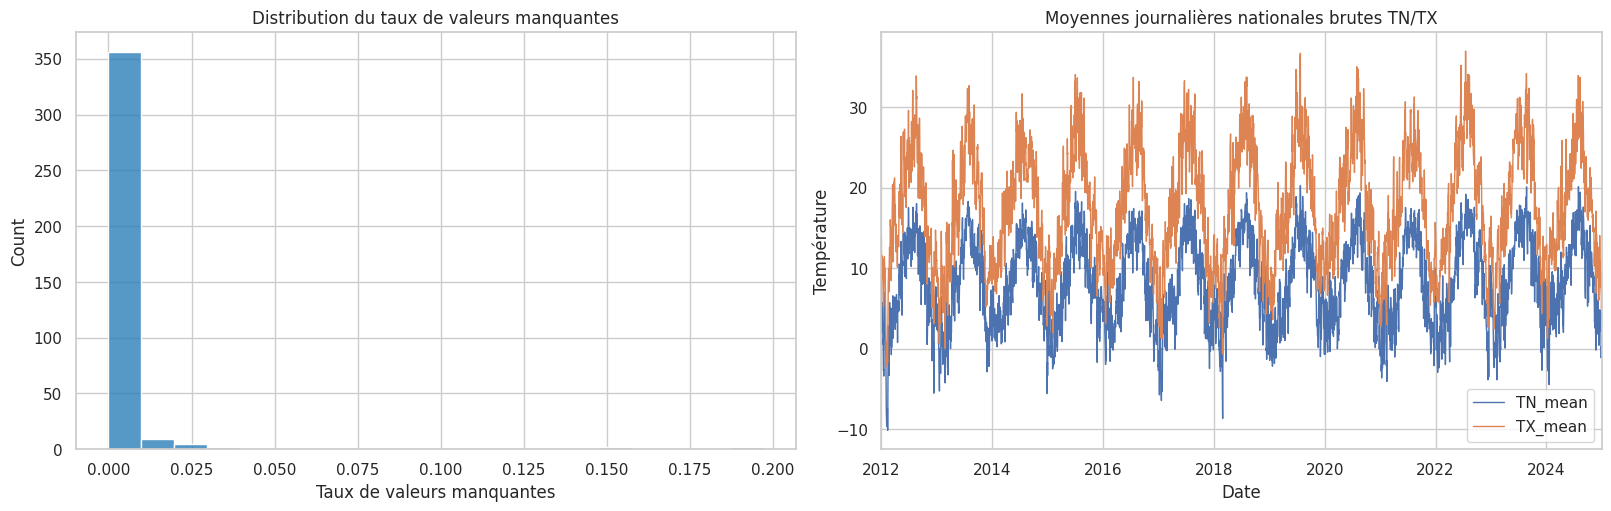

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

sns.histplot(missing_summary["missing_rate"], bins=20, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribution du taux de valeurs manquantes")
axes[0].set_xlabel("Taux de valeurs manquantes")

station_daily_mean = pd.DataFrame({
    "date": sqr_common["date"],
    "TN_mean": sqr_common[tn_columns].mean(axis=1, skipna=True),
    "TX_mean": sqr_common[tx_columns].mean(axis=1, skipna=True),
}).set_index("date")

station_daily_mean.plot(ax=axes[1], linewidth=1.0)
axes[1].set_title("Moyennes journalières nationales brutes TN/TX")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Température")

plt.show()

In [13]:
sqr_pca_frame = sqr_common[["date"] + all_temperature_columns].copy().set_index("date")

pca_experiments = {
    "all": fit_pca_experiment(sqr_pca_frame, all_temperature_columns, "all"),
    "tn": fit_pca_experiment(sqr_pca_frame, tn_columns, "tn"),
    "tx": fit_pca_experiment(sqr_pca_frame, tx_columns, "tx"),
}

explained_variance = pd.concat(
    [experiment["explained"] for experiment in pca_experiments.values()],
    ignore_index=True,
)

display(explained_variance.groupby("experiment").head(10))

,component,explained_variance_ratio,cumulative_explained_variance,experiment
0,1,0.845229,0.845229,all
1,2,0.044210,0.889439,all
2,3,0.019634,0.909073,all
3,4,0.010931,0.920004,all
4,5,0.009705,0.929708,all
5,6,0.008924,0.938633,all
6,7,0.004961,0.943594,all
7,8,0.003283,0.946877,all
8,9,0.002822,0.949698,all
9,10,0.002581,0.952279,all


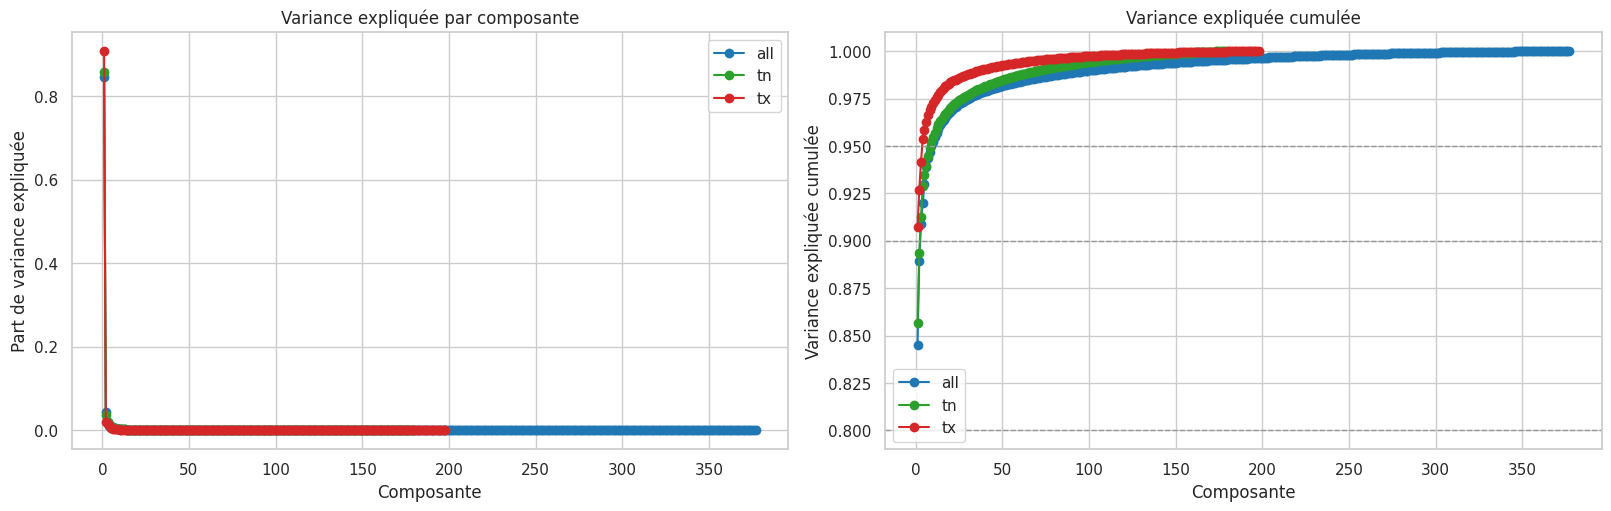

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
palette = {"all": "#1f77b4", "tn": "#2ca02c", "tx": "#d62728"}

for experiment_label, experiment in pca_experiments.items():
    explained = experiment["explained"]
    axes[0].plot(
        explained["component"],
        explained["explained_variance_ratio"],
        marker="o",
        linewidth=1.5,
        label=experiment_label,
        color=palette[experiment_label],
    )
    axes[1].plot(
        explained["component"],
        explained["cumulative_explained_variance"],
        marker="o",
        linewidth=1.5,
        label=experiment_label,
        color=palette[experiment_label],
    )

for threshold in [0.8, 0.9, 0.95]:
    axes[1].axhline(threshold, linestyle="--", linewidth=1.0, color="#999999")

axes[0].set_title("Variance expliquée par composante")
axes[0].set_xlabel("Composante")
axes[0].set_ylabel("Part de variance expliquée")
axes[0].legend()

axes[1].set_title("Variance expliquée cumulée")
axes[1].set_xlabel("Composante")
axes[1].set_ylabel("Variance expliquée cumulée")
axes[1].legend()

plt.show()

In [15]:
thresholds = [0.8, 0.9, 0.95]
rows = []

for experiment_label, experiment in pca_experiments.items():
    explained = experiment["explained"]
    for threshold in thresholds:
        rows.append({
            "experiment": experiment_label,
            "threshold": threshold,
            "components_needed": components_for_threshold(explained, threshold),
        })

components_summary = pd.DataFrame(rows)
display(components_summary)

,experiment,threshold,components_needed
0,all,0.80,1
1,all,0.90,3
2,all,0.95,10
3,tn,0.80,1
4,tn,0.90,3
5,tn,0.95,9
6,tx,0.80,1
7,tx,0.90,1
8,tx,0.95,4


In [16]:
selected_strategy = "all"
selected_threshold = 0.90
selected_components = int(
    components_summary.loc[
        (components_summary["experiment"] == selected_strategy)
        & np.isclose(components_summary["threshold"], selected_threshold),
        "components_needed",
    ].iloc[0]
)

selected_pipeline = build_pca_pipeline(n_components=selected_components)
selected_scores = selected_pipeline.fit_transform(sqr_pca_frame[pca_experiments[selected_strategy]["columns"]])
selected_feature_names = [f"temp_pc_{index:02d}" for index in range(1, selected_components + 1)]

sqr_pca_features = pd.DataFrame(
    selected_scores,
    index=sqr_pca_frame.index,
    columns=selected_feature_names,
).reset_index()

display(sqr_pca_features.head())
print(f"Stratégie sélectionnée: {selected_strategy}")
print(f"Seuil de variance retenu: {selected_threshold:.0%}")
print(f"Nombre de composantes sélectionné: {selected_components}")

,date,temp_pc_01,temp_pc_02,temp_pc_03
0,2012-01-01,-3.338610,6.849751,5.413269
1,2012-01-02,-14.100261,4.370491,0.697807
2,2012-01-03,-15.249291,-1.146179,2.822054
3,2012-01-04,-15.667742,3.208044,2.546018
4,2012-01-05,-12.303847,3.125173,5.623418


Stratégie sélectionnée: all
Seuil de variance retenu: 90%
Nombre de composantes sélectionné: 3


In [17]:
candidate_join_frame = rte_daily_coverage[["date"]].merge(sqr_pca_features, on="date", how="left")

print(f"Shape du futur bloc de features PCA: {candidate_join_frame.shape}")
display(candidate_join_frame.head())

Shape du futur bloc de features PCA: (4749, 4)


,date,temp_pc_01,temp_pc_02,temp_pc_03
0,2012-01-01,-3.338610,6.849751,5.413269
1,2012-01-02,-14.100261,4.370491,0.697807
2,2012-01-03,-15.249291,-1.146179,2.822054
3,2012-01-04,-15.667742,3.208044,2.546018
4,2012-01-05,-12.303847,3.125173,5.623418
